# Olist churned prediction

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import lightgbm as lgb
#import optuna

In [5]:
df = pd.read_parquet("C:\LightGBM project\outputs\olist_processed.parquet")
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [6]:
#Create churn label
last_date = df["order_purchase_timestamp"].max()

customer_last = df.groupby("customer_unique_id")["order_purchase_timestamp"].max()

churn = (last_date - customer_last > pd.Timedelta(days=90)).astype(int)

df = df.merge(churn.rename("churn"), on="customer_unique_id", how="left")

### Feature Engineering

In [7]:
df["recency"] = (last_date - df["order_purchase_timestamp"]).dt.days

freq = df.groupby("customer_unique_id")["order_id"].count()
df = df.merge(freq.rename("frequency"), on="customer_unique_id", how="left")

monetary = df.groupby("customer_unique_id")["price"].sum()
df = df.merge(monetary.rename("monetary"), on="customer_unique_id", how="left")

df["avg_order_value"] = df["monetary"] / df["frequency"]

df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

In [8]:
features = [
    "recency",
    "frequency",
    "monetary",
    "avg_order_value",
    "delivery_days",
    "price",
    "freight_value"
]

model_df = df[features + ["churn"]]
model_df.head()

,recency,frequency,monetary,avg_order_value,delivery_days,price,freight_value,churn
0,380,4,125.36,31.34,8.0,29.99,8.72,1
1,380,4,125.36,31.34,8.0,29.99,8.72,1
2,380,4,125.36,31.34,8.0,29.99,8.72,1
3,84,1,118.70,118.70,13.0,118.70,22.76,0
4,70,1,159.90,159.90,9.0,159.90,19.22,0


In [9]:
model_df["churn"].value_counts()

churn
1    107673
0     11470
Name: count, dtype: int64

In [10]:
model_df.shape

(119143, 8)

In [11]:
model_df.isnull().sum().sort_values(ascending=False)

delivery_days      3421
recency               0
frequency             0
monetary              0
avg_order_value       0
price                 0
freight_value         0
churn                 0
dtype: int64

In [12]:
model_df = df[features + ["churn"]].dropna()
model_df.shape

(115722, 8)

In [13]:
model_df["churn"].value_counts()

churn
1    104534
0     11188
Name: count, dtype: int64

### Balance the dataset

In [14]:

from imblearn.over_sampling import SMOTE

In [15]:
X = model_df.drop(columns=["churn"])
y = model_df["churn"]

In [16]:
# Apply SMOTE
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

# Check balance
print(y_resampled.value_counts())

churn
1    104534
0    104534
Name: count, dtype: int64


In [17]:
#Time free split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Optuna Hyperparameter Tuning

use to find best LightGBM settings by tring different hyperparameter values on each trial repeatedly.

In [18]:
import optuna

In [19]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),#number of trees
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "num_leaves": trial.suggest_int("num_leaves", 20, 120),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100)
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Params:", study.best_params)

[I 2026-05-28 12:41:25,910] A new study created in memory with name: no-name-9447f979-cce8-4077-a36a-5d039dd796ab


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000781 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:41:30,929] Trial 0 finished with value: 0.9983199780909823 and parameters: {'n_estimators': 129, 'learning_rate': 0.08650640556175809, 'num_leaves': 22, 'max_depth': 11, 'min_child_samples': 74}. Best is trial 0 with value: 0.9983199780909823.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000839 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:32,386] Trial 1 finished with value: 0.9980082439218784 and parameters: {'n_estimators': 397, 'learning_rate': 0.17931283119401625, 'num_leaves': 94, 'max_depth': 8, 'min_child_samples': 67}. Best is trial 0 with value: 0.9983199780909823.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:32,874] Trial 2 finished with value: 0.9984431030428684 and parameters: {'n_estimators': 179, 'learning_rate': 0.19806652673789174, 'num_leaves': 54, 'max_depth': 6, 'min_child_samples': 70}. Best is trial 2 with value: 0.9984431030428684.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000625 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:33,840] Trial 3 finished with value: 0.9983276934368651 and parameters: {'n_estimators': 446, 'learning_rate': 0.12789766141297543, 'num_leaves': 27, 'max_depth': 5, 'min_child_samples': 35}. Best is trial 2 with value: 0.9984431030428684.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000701 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:34,640] Trial 4 finished with value: 0.9984606923217092 and parameters: {'n_estimators': 583, 'learning_rate': 0.10561508870304197, 'num_leaves': 80, 'max_depth': 3, 'min_child_samples': 79}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:35,628] Trial 5 finished with value: 0.9984306217077006 and parameters: {'n_estimators': 214, 'learning_rate': 0.1726009773509856, 'num_leaves': 116, 'max_depth': 10, 'min_child_samples': 95}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000549 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:37,403] Trial 6 finished with value: 0.9978884743974261 and parameters: {'n_estimators': 533, 'learning_rate': 0.190974481487724, 'num_leaves': 96, 'max_depth': 10, 'min_child_samples': 57}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:38,176] Trial 7 finished with value: 0.9983034574196045 and parameters: {'n_estimators': 379, 'learning_rate': 0.19015466288499963, 'num_leaves': 55, 'max_depth': 5, 'min_child_samples': 64}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000634 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:38,897] Trial 8 finished with value: 0.9983906344164354 and parameters: {'n_estimators': 166, 'learning_rate': 0.10884916481075589, 'num_leaves': 98, 'max_depth': 11, 'min_child_samples': 30}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:40,229] Trial 9 finished with value: 0.9982615038906075 and parameters: {'n_estimators': 374, 'learning_rate': 0.1413916691239808, 'num_leaves': 46, 'max_depth': 10, 'min_child_samples': 63}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000730 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:41,118] Trial 10 finished with value: 0.9980613537127889 and parameters: {'n_estimators': 597, 'learning_rate': 0.034416360264082346, 'num_leaves': 75, 'max_depth': 3, 'min_child_samples': 98}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-28 12:41:41,542] Trial 11 finished with value: 0.9978151892976141 and parameters: {'n_estimators': 264, 'learning_rate': 0.06229020519030368, 'num_leaves': 68, 'max_depth': 3, 'min_child_samples': 84}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-28 12:41:42,223] Trial 12 finished with value: 0.9974372335240284 and parameters: {'n_estimators': 285, 'learning_rate': 0.015056031345318785, 'num_leaves': 46, 'max_depth': 6, 'min_child_samples': 43}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-28 12:41:43,832] Trial 13 finished with value: 0.9981283340285693 and parameters: {'n_estimators': 483, 'learning_rate': 0.14998042996858557, 'num_leaves': 78, 'max_depth': 7, 'min_child_samples': 11}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:44,345] Trial 14 finished with value: 0.9982639403156229 and parameters: {'n_estimators': 296, 'learning_rate': 0.07231141825796818, 'num_leaves': 66, 'max_depth': 4, 'min_child_samples': 81}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000792 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:44,657] Trial 15 finished with value: 0.9982961481445576 and parameters: {'n_estimators': 105, 'learning_rate': 0.10772354224018031, 'num_leaves': 37, 'max_depth': 8, 'min_child_samples': 49}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:46,117] Trial 16 finished with value: 0.9982043975077851 and parameters: {'n_estimators': 598, 'learning_rate': 0.1614901080544145, 'num_leaves': 84, 'max_depth': 6, 'min_child_samples': 86}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000810 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:46,453] Trial 17 finished with value: 0.997518330144395 and parameters: {'n_estimators': 177, 'learning_rate': 0.04865548627552781, 'num_leaves': 57, 'max_depth': 4, 'min_child_samples': 75}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000778 seconds.
Y

[I 2026-05-28 12:41:47,961] Trial 18 finished with value: 0.9973273913629074 and parameters: {'n_estimators': 513, 'learning_rate': 0.13211533775282783, 'num_leaves': 114, 'max_depth': 7, 'min_child_samples': 89}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000582 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:48,566] Trial 19 finished with value: 0.998392899864257 and parameters: {'n_estimators': 328, 'learning_rate': 0.0963064518742181, 'num_leaves': 86, 'max_depth': 4, 'min_child_samples': 73}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234

[I 2026-05-28 12:41:49,097] Trial 20 finished with value: 0.9973908987044332 and parameters: {'n_estimators': 243, 'learning_rate': 0.01554215677488037, 'num_leaves': 58, 'max_depth': 6, 'min_child_samples': 54}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000613 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:49,966] Trial 21 finished with value: 0.9983396832126 and parameters: {'n_estimators': 215, 'learning_rate': 0.16910284364379208, 'num_leaves': 118, 'max_depth': 9, 'min_child_samples': 96}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number 

[I 2026-05-28 12:41:50,945] Trial 22 finished with value: 0.9982493217655293 and parameters: {'n_estimators': 203, 'learning_rate': 0.1928431338849397, 'num_leaves': 111, 'max_depth': 12, 'min_child_samples': 90}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:51,563] Trial 23 finished with value: 0.9983879842699273 and parameters: {'n_estimators': 146, 'learning_rate': 0.19945673667439814, 'num_leaves': 104, 'max_depth': 9, 'min_child_samples': 100}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000442 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:52,477] Trial 24 finished with value: 0.9982149553495195 and parameters: {'n_estimators': 320, 'learning_rate': 0.16742580020383058, 'num_leaves': 41, 'max_depth': 9, 'min_child_samples': 79}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:52,973] Trial 25 finished with value: 0.9983768280080136 and parameters: {'n_estimators': 230, 'learning_rate': 0.1542835737597591, 'num_leaves': 84, 'max_depth': 5, 'min_child_samples': 69}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:53,655] Trial 26 finished with value: 0.9983929426085555 and parameters: {'n_estimators': 185, 'learning_rate': 0.12437994946299163, 'num_leaves': 62, 'max_depth': 12, 'min_child_samples': 92}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000800 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:41:54,270] Trial 27 finished with value: 0.9984226285238774 and parameters: {'n_estimators': 425, 'learning_rate': 0.17711056502755734, 'num_leaves': 109, 'max_depth': 3, 'min_child_samples': 80}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-28 12:41:54,681] Trial 28 finished with value: 0.9981483811045752 and parameters: {'n_estimators': 119, 'learning_rate': 0.17940283631415438, 'num_leaves': 120, 'max_depth': 7, 'min_child_samples': 58}. Best is trial 4 with value: 0.9984606923217092.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-28 12:41:55,082] Trial 29 finished with value: 0.9986741787206658 and parameters: {'n_estimators': 145, 'learning_rate': 0.09256368284464249, 'num_leaves': 31, 'max_depth': 11, 'min_child_samples': 92}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000818 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:41:56,261] Trial 30 finished with value: 0.9984732377733248 and parameters: {'n_estimators': 553, 'learning_rate': 0.08177664077788087, 'num_leaves': 24, 'max_depth': 11, 'min_child_samples': 75}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:41:57,389] Trial 31 finished with value: 0.9984723187709066 and parameters: {'n_estimators': 546, 'learning_rate': 0.08124297378119047, 'num_leaves': 20, 'max_depth': 11, 'min_child_samples': 73}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:41:58,440] Trial 32 finished with value: 0.9983462017181242 and parameters: {'n_estimators': 537, 'learning_rate': 0.08488682795678547, 'num_leaves': 21, 'max_depth': 11, 'min_child_samples': 77}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:41:59,837] Trial 33 finished with value: 0.9982669110443702 and parameters: {'n_estimators': 575, 'learning_rate': 0.084557303368269, 'num_leaves': 32, 'max_depth': 12, 'min_child_samples': 85}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000563 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:00,974] Trial 34 finished with value: 0.9983669327029063 and parameters: {'n_estimators': 486, 'learning_rate': 0.0662315813055268, 'num_leaves': 28, 'max_depth': 11, 'min_child_samples': 71}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:02,090] Trial 35 finished with value: 0.9984937550366142 and parameters: {'n_estimators': 565, 'learning_rate': 0.09639479681222463, 'num_leaves': 20, 'max_depth': 10, 'min_child_samples': 65}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000533 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:03,289] Trial 36 finished with value: 0.99839973895202 and parameters: {'n_estimators': 552, 'learning_rate': 0.09562975930792667, 'num_leaves': 26, 'max_depth': 10, 'min_child_samples': 64}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000569 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:04,210] Trial 37 finished with value: 0.9982422689562735 and parameters: {'n_estimators': 457, 'learning_rate': 0.11761616355445534, 'num_leaves': 21, 'max_depth': 11, 'min_child_samples': 50}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000582 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:05,452] Trial 38 finished with value: 0.998382619860463 and parameters: {'n_estimators': 501, 'learning_rate': 0.07309261620144339, 'num_leaves': 34, 'max_depth': 11, 'min_child_samples': 61}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:06,661] Trial 39 finished with value: 0.998406214713246 and parameters: {'n_estimators': 560, 'learning_rate': 0.04945957184162238, 'num_leaves': 27, 'max_depth': 12, 'min_child_samples': 67}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000669 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[I 2026-05-28 12:42:07,918] Trial 40 finished with value: 0.9981380583564825 and parameters: {'n_estimators': 410, 'learning_rate': 0.09357439500319059, 'num_leaves': 42, 'max_depth': 10, 'min_child_samples': 41}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000681 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:09,011] Trial 41 finished with value: 0.9982796274731798 and parameters: {'n_estimators': 572, 'learning_rate': 0.1154054258742677, 'num_leaves': 20, 'max_depth': 10, 'min_child_samples': 75}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000572 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:42:10,221] Trial 42 finished with value: 0.998430001915372 and parameters: {'n_estimators': 524, 'learning_rate': 0.08022238333707826, 'num_leaves': 31, 'max_depth': 8, 'min_child_samples': 70}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000604 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

[I 2026-05-28 12:42:11,686] Trial 43 finished with value: 0.9981164938578794 and parameters: {'n_estimators': 451, 'learning_rate': 0.1032324687408077, 'num_leaves': 51, 'max_depth': 9, 'min_child_samples': 83}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000568 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:12,864] Trial 44 finished with value: 0.9985709298675914 and parameters: {'n_estimators': 540, 'learning_rate': 0.05627775214093352, 'num_leaves': 26, 'max_depth': 11, 'min_child_samples': 91}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000645 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:13,988] Trial 45 finished with value: 0.9984684076675919 and parameters: {'n_estimators': 537, 'learning_rate': 0.053917872999042084, 'num_leaves': 25, 'max_depth': 11, 'min_child_samples': 95}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000617 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:15,170] Trial 46 finished with value: 0.998425471019729 and parameters: {'n_estimators': 470, 'learning_rate': 0.03603449144460984, 'num_leaves': 37, 'max_depth': 12, 'min_child_samples': 89}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:16,246] Trial 47 finished with value: 0.998609228759065 and parameters: {'n_estimators': 509, 'learning_rate': 0.0760923153547827, 'num_leaves': 24, 'max_depth': 11, 'min_child_samples': 23}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:17,476] Trial 48 finished with value: 0.9981850770848543 and parameters: {'n_estimators': 503, 'learning_rate': 0.06135162896920433, 'num_leaves': 36, 'max_depth': 10, 'min_child_samples': 10}. Best is trial 29 with value: 0.9986741787206658.


[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


[I 2026-05-28 12:42:18,679] Trial 49 finished with value: 0.9983333143121204 and parameters: {'n_estimators': 589, 'learning_rate': 0.038717822614048415, 'num_leaves': 25, 'max_depth': 11, 'min_child_samples': 20}. Best is trial 29 with value: 0.9986741787206658.


Best Params: {'n_estimators': 145, 'learning_rate': 0.09256368284464249, 'num_leaves': 31, 'max_depth': 11, 'min_child_samples': 92}


### Train Final Model

In [21]:
best_model = lgb.LGBMClassifier(**study.best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 83627, number of negative: 8950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 92577, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.903324 -> initscore=2.234713
[LightGBM] [Info] Start training from score 2.234713


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,11
,learning_rate,0.09256368284464249
,n_estimators,145
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,92


### Prediction

In [22]:
probs = best_model.predict_proba(X_test)[:, 1]

### Treshold tuning

In [23]:
#because churn data is often imbalance

from sklearn.metrics import precision_recall_curve


precision, recall, thresholds = precision_recall_curve(y_test, probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)

Best Threshold: 0.6178087800534856


### Final prediction using best threshold

In [24]:
final_preds = (probs >= best_threshold).astype(int)

### Final evaluation

In [25]:
print("ROC AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, final_preds))

ROC AUC: 0.9986741787206658
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2238
           1       1.00      1.00      1.00     20907

    accuracy                           1.00     23145
   macro avg       1.00      0.99      0.99     23145
weighted avg       1.00      1.00      1.00     23145



### Feature importance

In [26]:
import matplotlib.pyplot as plt

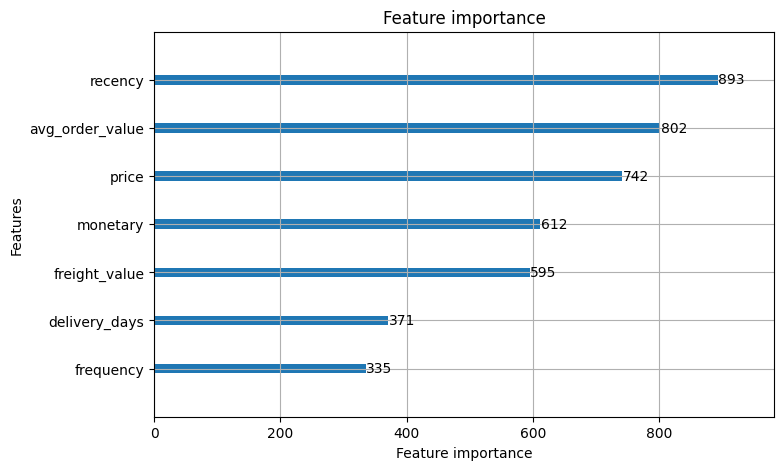

In [27]:
lgb.plot_importance(best_model, figsize=(8,5))
plt.show()

In [28]:
df['customer_id'].duplicated().sum()

19702

In [30]:
df["churn"].value_counts()

churn
1    107673
0     11470
Name: count, dtype: int64

### Risk segmentation

In [31]:
result = X_test.copy()
result["churn_prob"] = probs

result["segment"] = pd.cut(
    result["churn_prob"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

result["segment"].value_counts()

segment
High Risk      20950
Low Risk        2179
Medium Risk       16
Name: count, dtype: int64

# SHAP Explainability

In [32]:
import shap

c:\Users\Nuwani Hitibandara\AppData\Local\Programs\Python\Python311\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


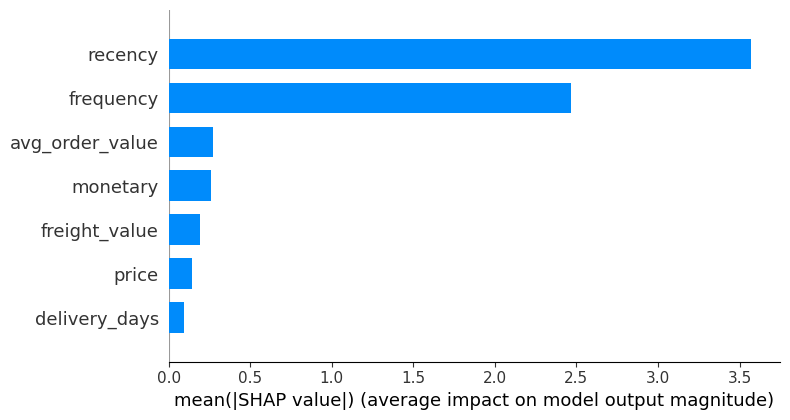

In [33]:
#Create shap explainer
explainer = shap.TreeExplainer(best_model)
#Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

### Explain one customer prediction

In [34]:
customer_id = 5

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_id],
    X_test.iloc[customer_id]
)

In [35]:
#Save model
best_model.booster_.save_model("olist_lgbm_final.txt")
print("Model saved successfully!")

Model saved successfully!


In [36]:
import pickle

# Save the model
with open('model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [37]:

import joblib


joblib.dump(X_train.columns.tolist(), "features.pkl")

['features.pkl']